## 2. Pytorch Nerual Network Classfication

分类问题是预测

| Problem type | What is it? | Example |
| --- | --- | --- |
| 二分类 Binary classification | 是或者不是 | 通过某人的体检特征预测他是否有心脏病 |
| 多分类 Multi-class classification | 可以超过2个选项 | 检测图片是食物、狗还是人 |
| 多标签分类 Multi-label classification | 可以有多个标签 | 预测一篇文章的类型（可以有多个）(e.g. mathematics, science & philosophy) |

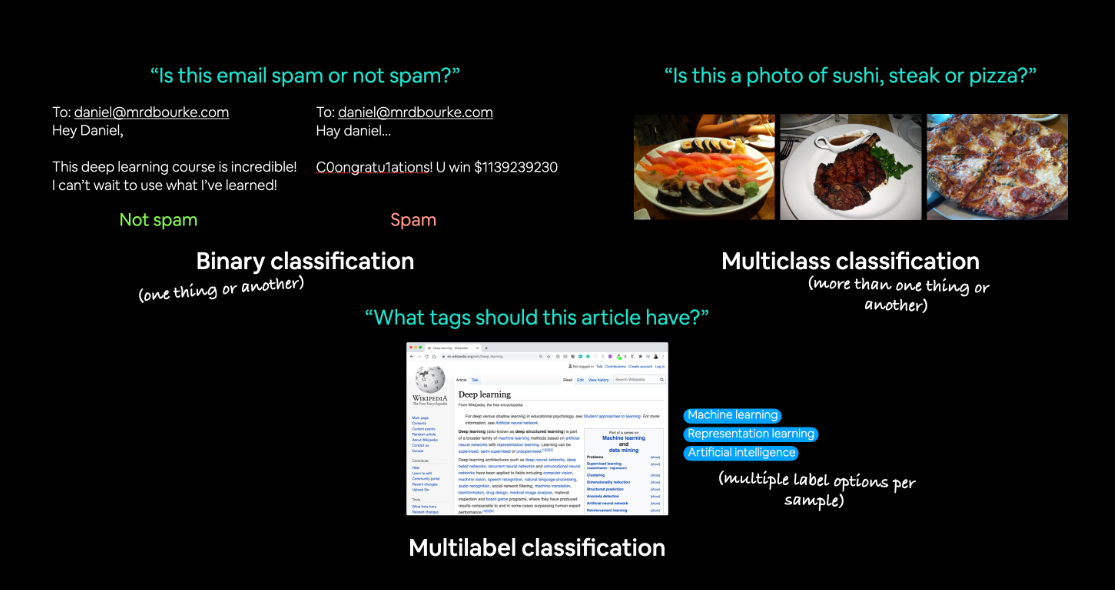

分类和回归问题都是机器学习里常见的问题，本章流程和第一章基本一致，但是这次预测的不再只是一条直线

| Topic | Contents |
| --- | --- |
| 0. 分类神经网络的架构（Architecture） | 神经网络几乎可以有任何形状或大小，但它们通常遵循类似的平面图。 |
| 1. 准备二分类数据 | 数据几乎可以是任何东西，但要开始，我们将创建一个简单的二进制分类数据集。 |
| 2. 创建PyTorch分类模型 | 创建模型，损失函数loss function, 优化器optimizer，构建 training loop |
| 3. 训练(training) | training data. |
| 4. 评价(inference) | testing data. |
| 5. 优化模型 (from a model perspective) | 我们已经训练了一个评估模型，但它不起作用，让我们尝试一些方法来改进它。 |
| 6. 非线性 | 到目前为止，我们的模型只能对直线进行建模，那么非线性（非直线）线呢？ |
| 7. 复制非线性函数 | 我们使用非线性函数来帮助对非线性数据进行建模，但它们是什么样的？ |
| 8. 使用上述步骤解决多分类问题 | 让我们把到目前为止我们为二元分类所做的一切与一个多类分类问题放在一起。 |

### 0. 分类神经网络的架构

| 超参数名称 | 二分类任务 (Binary Classification) | 多分类任务 (Multiclass classification) |
| :--- | :--- | :--- |
| 输入层形状<br>(`in_features`) | 特征的个数（比如预测心脏病要用到：年龄、性别、身高、体重、吸烟状态，共5个特征） | 和二分类一样 |
| 隐藏层数量 | 看具体问题决定，最少1层，最多不限 | 和二分类一样 |
| 每个隐藏层的神经元数 | 看具体问题，通常范围是 10 到 512 个 | 和二分类一样 |
| 输出层形状<br>(`out_features`) | 输出1个值（判断是或不是） | 每个类别输出1个值（比如分3类：食物、人、狗，就输出3个值） |
| 隐藏层激活函数 | 常用 ReLU（整流线性单元），其他也可以 | 和二分类一样 |
| 输出层激活函数 | Sigmoid（在 PyTorch 中用 `torch.sigmoid`） | Softmax（在 PyTorch 中用 `torch.softmax`） |
| 损失函数 | 二元交叉熵<br>（在 PyTorch 中用 `torch.nn.BCELoss`） | 交叉熵<br>（在 PyTorch 中用 `torch.nn.CrossEntropyLoss`） |
| 优化器 | SGD（随机梯度下降）、Adam（更多选项见 `torch.optim`） | 和二分类一样 |

### 1. 准备分类数据

使用Scikit-Learn的```make_circles()```方法生成圆。

In [61]:
# 导入环形数据生成工具（scikit-learn内置）
from sklearn.datasets import make_circles

# 设置样本数量：一共生成1000个数据点
n_samples = 1000

# 创建环形分布的数据集（二分类任务专用）
X, y = make_circles(
    n_samples,        # 数据点总数
    noise=0.03,       # 给数据加一点噪声（让点不完全在圆环上，更贴近真实数据）
    random_state=42   # 固定随机种子，保证每次运行生成的数据集完全一致
)

现在我们来查看前 5 个 X 和 y 的数值。

In [62]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


看起来每一个 y 值对应两个 X 值。

让我们继续遵循数据探索的核心原则：可视化、可视化、再可视化，并把这些数据放进 pandas 数据框里。

In [63]:
# 创建环形数据的DataFrame（数据表格）
import pandas as pd
circles = pd.DataFrame({
    "X1": X[:, 0],  # 取X的第一列作为特征X1
    "X2": X[:, 1],  # 取X的第二列作为特征X2
    "label": y      # 标签（0或1，代表内圈/外圈）
})
# 查看前10行数据
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


看起来每一组 X 特征（X1 和 X2）都对应一个标签值 y，标签只有 0 或者 1。

这说明我们要解决的是二分类问题，因为只有两个分类选项（0 或 1）。

每个类别分别有多少个样本呢？

In [64]:
# 统计不同标签的数量，pandas方法
circles['label'].value_counts()

label
1    500
0    500
Name: count, dtype: int64

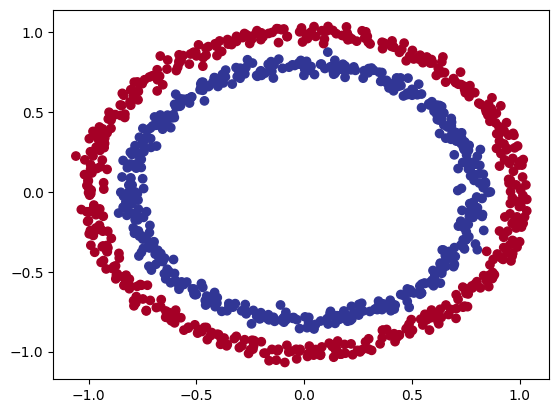

In [65]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

让我们看看如何构建一个 PyTorch 神经网络来将点分类为红色 (0) 或蓝色 (1)。

>注意：该数据集通常被认为是机器学习中的玩具问题（用于尝试和测试模型的问题）。
但它代表了分类任务的核心思想：你拥有一组用数值表示的数据，想要搭建一个模型对这些数据进行分类——在我们的案例中，就是把数据分成红点或蓝点。

深度学习中最常见的错误之一就是**形状不匹配错误**。

张量与张量运算的形状对不上，就会直接导致模型运行报错。

在整个课程里，我们会大量遇到这类问题。

没有任何方法能保证绝对不出现形状错误，它们总会发生。

你能做的就是**不断熟悉你正在使用的数据形状**。

我习惯把它叫作**输入形状和输出形状**。

问自己两个问题：
“我的输入数据是什么形状？”
“我的输出结果是什么形状？”

让我们一起来搞清楚这一点。

In [66]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

看起来第一维是匹配的。

一共有 1000 个 X 数据和 1000 个 y 标签。

但是 X 的第二维呢？

查看单个样本的特征、标签的值和形状，能帮你搞清楚模型期望的输入形状和输出形状。

In [67]:
# 查看第一个特征和标签样本
X_sample = X[0]  # 取第一个数据特征
y_sample = y[0]  # 取第一个数据标签

# 打印单个样本的数值
print(f"一个X样本的数值：{X_sample}，对应的y标签：{y_sample}")
# 打印单个样本的形状（非常重要，用于检查模型输入输出尺寸）
print(f"一个X样本的形状：{X_sample.shape}，对应的y标签形状：{y_sample.shape}")

一个X样本的数值：[0.75424625 0.23148074]，对应的y标签：1
一个X样本的形状：(2,)，对应的y标签形状：()


X有2个特征 (vector)而 y 有一个 特征(scalar).

两个输入对应一个输出。

#### 1.2 将数据转成tensors并切割训练集和测试集

我们已经研究了数据的输入和输出形状，现在让我们准备将其用于建模。

具体来说，我们需要完成两步：
1. 将数据转换成张量（tensors）
2. 把数据集切分为训练集和测试集

In [68]:
# 将数据转换为张量（tensors）
# 不做这一步后续计算会报错
import torch

# 把 numpy 数组转为 PyTorch 张量，并指定数据类型为 float
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# 查看前 5 个样本
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

将数据转换为张量格式后，需要对数据集进行划分，用于模型训练与效果评估。

这里使用 Scikit-Learn提供的train_test_split 工具，按照 80% 训练集、20% 测试集 的比例进行切分，并设置固定随机种子保证结果可复现。

In [69]:
# 划分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # 测试集占比 20%，训练集占比 80%
    random_state=42   # 固定随机种子，保证分割结果可复现
)

# 查看数据集长度
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

### 2. 构建模型

整体流程与上一节 01 相似，只需根据当前任务做少量调整。
1. 设置运行设备（device），让模型自动使用 CPU / 可用 GPU
2. 继承 `nn.Module` 构建分类神经网络模型
3. 定义损失函数（loss function）与优化器（optimizer）
4. 构建训练循环（training loop）（下一节实现）

In [70]:
# 导入 PyTorch 核心模块
import torch
from torch import nn

# 设备配置：自动检测是否有可用 GPU，有则用 cuda，无则用 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"

# 查看当前使用设备
device

'cuda'

接下来如何构建模型？

模型应该接收X，输出y。

也就是说, 给定X (features) ，模型应该预测出 y (label).

这种具有特征和标签的设置称为监督学习。 因为你的数据告诉你的模型应该给什么输出一个特定的输入。

需要处理 X 和 y的形状。

让我们通过下面步骤创建模型：
1. 定义模型类 → 继承 nn.Module。所有自定义模型必须子类化 nn.Module，这是 PyTorch 的强制规范，自动获得模型训练、评估、参数更新的基础能力。
2. 构造函数 __init__ → 定义网络层。在构造函数中初始化可学习层（这里用 2 个nn.Linear线性层，适配X和y的形状）：
   - 输入层：匹配特征X的输入维度
   - 输出层：匹配标签y的输出维度
   - 中间层：自定义隐藏维度（控制模型复杂度）
3. 定义 forward() 方法 → 实现前向计算。模型的核心计算逻辑，接收输入X，逐层计算后输出预测值，PyTorch 会自动调用该方法完成前向传播。
4. 实例化模型 + 迁移到指定设备。创建模型对象，将模型移动到 CPU/GPU（加速计算，必须和数据设备一致）

In [71]:
# ==============================================
# 1. 核心：自定义模型类，必须继承 nn.Module
# PyTorch 所有模型都必须是 nn.Module 的子类
# ==============================================
class CircleModelV0(nn.Module):
    # 构造函数：初始化网络层
    def __init__(self):
        super().__init__()  # 调用父类初始化（固定写法，必须写）

        # ==============================================
        # 2. 定义 2 个线性层 nn.Linear
        # 严格匹配输入 X 和输出 y 的形状
        # ==============================================
        # 第一层：输入2个特征 → 输出5个隐藏特征
        # 适配：X 是 2 维数据（比如坐标 x1, x2）
        self.layer_1 = nn.Linear(in_features=2, out_features=5)

        # 第二层：输入5个隐藏特征 → 输出1个预测值
        # 适配：y 是 1 维标签（分类/回归任务）
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    # ==============================================
    # 3. 前向传播 forward()：模型计算流程
    # 自动被调用，定义数据如何流过网络
    # ==============================================
    def forward(self, x):
        # 计算顺序：先过 layer_1 → 再过 layer_2
        # 等价于：x = self.layer_1(x) → x = self.layer_2(x)
        return self.layer_2(self.layer_1(x))

# ==============================================
# 4. 实例化模型 + 迁移到设备
# ==============================================
model_0 = CircleModelV0().to(device)

# 查看模型结构（验证是否正确）
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

layer_1
   - 输入：2 个特征（X 的维度）
   - 输出：5 个特征（隐藏单元 / 神经元）
   - 作用：将 2 维特征 → 升维到 5 维，提升模型学习能力

layer_2
   - 输入：5 个特征（必须 = 上一层输出）
   - 输出：1 个特征（与标签 y 的形状一致）

为什么要 2 → 5？
   - 原始特征太少，学习能力有限
   - 增加隐藏单元 = 给模型更多数字学习模式
   - 表达能力更强，可能学习更复杂的规律
   - 不是一定提升，取决于数据

隐藏单元数量
   - 属于 超参数（hyperparameter）
   - 自己设置，无固定答案
   - 简单数据集 → 少量隐藏单元
   - 复杂数据集 → 更多隐藏单元
   - 太多会过拟合，太少会欠拟合

下一层的 in_features = 上一层的 out_features否则直接报错

最后一层 out_features = 标签 y 的维度

可以在 TensorFlow Playground 网站上亲手搭建一个属于你自己的模型。https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.27222&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false

上述操作也可以用 `nn.Sequential`实现，和之前手写 class 定义的模型功能完全一样，只是写法更简洁

`nn.Sequential` 按照它们出现的顺序通过层执行输入数据的前向传递计算。

In [72]:
# 用 nn.Sequential 复现 CircleModelV0
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),  # 第一层：2 → 5（隐藏层）
    nn.Linear(in_features=5, out_features=1)   # 第二层：5 → 1（输出层）
).to(device)  # 移动到设备

# 查看模型结构
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

`nn.Sequential` 写法更简单，但**只能做顺序计算**；
自定义 `nn.Module` 更灵活，能实现任意复杂计算。

In [73]:
# 用模型进行预测（未训练模型的预测）
untrained_preds = model_0(X_test.to(device))

# 查看预测结果的长度、形状
print(f"预测值长度: {len(untrained_preds)}, 形状: {untrained_preds.shape}")
print(f"测试集样本长度: {len(y_test)}, 形状: {y_test.shape}")

# 查看前 10 个预测值与真实标签
print(f"\n前 10 个预测值:\n{untrained_preds[:10]}")
print(f"\n前 10 个真实标签:\n{y_test[:10]}")

预测值长度: 200, 形状: torch.Size([200, 1])
测试集样本长度: 200, 形状: torch.Size([200])

前 10 个预测值:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0', grad_fn=<SliceBackward0>)

前 10 个真实标签:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


预测的数量与测试标签的数量相同，但预测看起来与测试标签的形式或形状不同。

我们有几个步骤可以解决这个问题，我们稍后会看到

#### 2.1 设置loss function和optimizer

不同的的问题需要不同的loss，例如回归问题(predicting a number)可能用MAE loss.二分类问题 (like ours),可能用 binary cross entropy。而优化器则是通用的。

| 损失函数/优化器 | 适用任务类型 | PyTorch 代码 |
| :--- | :--- | :--- |
| 随机梯度下降 (SGD) 优化器 | 分类、回归及其他多数任务 | `torch.optim.SGD()` |
| Adam 优化器 | 分类、回归及其他多数任务 | `torch.optim.Adam()` |
| 二元交叉熵损失 | 二分类任务 | `torch.nn.BCEWithLogitsLoss` 或 `torch.nn.BCELoss` |
| 交叉熵损失 | 多分类任务 | `torch.nn.CrossEntropyLoss` |
| 平均绝对误差 (MAE / L1 Loss) | 回归任务 | `torch.nn.L1Loss` |
| 均方误差 (MSE / L2 Loss) | 回归任务 | `torch.nn.MSELoss` |

深度学习中最常用的一批损失函数与优化器

本节任务为二分类问题，因此可以使用二元交叉熵损失函数。
>注意：损失函数用于衡量模型预测的错误程度，损失值越高，代表模型效果越差。另外，PyTorch 文档中经常将损失函数称为“loss criterion”或“criterion”，这些名称描述的是同一个概念。

二元交叉熵在 PyTorch 中有两种实现方式：
   1. torch.nn.BCELoss()：用于计算目标标签与输入之间的二元交叉熵。
   2. torch.nn.BCEWithLogitsLoss()：功能与上述相同，但内部内置了sigmoid层。

我们该使用哪一个？
PyTorch 官方文档指出，BCEWithLogitsLoss() 比在 nn.Sigmoid 后使用 BCELoss() 数值上更加稳定。
因此，通常选择第二种方式。只有在高级用法中，才可能需要将 Sigmoid 和 BCELoss 分开使用，但这不在本节内容范围内。

优化器使用 torch.optim.SGD()，学习率设置为 0.1。

>注意：PyTorch 社区中经常有关于 BCELoss 与 BCEWithLogitsLoss 用法的讨论。一开始可能会令人困惑，但和许多知识点一样，通过练习会逐渐变得清晰。

In [74]:
# 创建损失函数
# loss_fn = nn.BCELoss()  # BCELoss = 不带内置Sigmoid，需要手动添加
loss_fn = nn.BCEWithLogitsLoss()  # BCEWithLogitsLoss = 自带Sigmoid层，数值更稳定

# 创建优化器
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

现在让我们也创建一个评估指标。
评估指标可用于提供有关模型运行方式的另一种观点。
如果损失函数衡量模型的错误程度，我喜欢将评估指标视为衡量模型的正确程度。

当然，你可以说两者做的是同一件事，但评估指标提供了不同的视角。
毕竟，在评估你的模型时，最好从多个角度看待事物。

有几个评估指标可用于分类问题，但让我们从准确率（accuracy）开始。

准确率可以通过将正确预测的总数除以总预测数来衡量。
例如，一个模型在 100 个样本中做出 99 个正确预测，它的准确率就是 99%。

让我们编写一个函数来做到这一点。

In [75]:
# 计算准确率（分类任务评估指标）
def accuracy_fn(y_true, y_pred):
    # 逐元素对比真实值和预测值，统计正确预测的数量
    correct = torch.eq(y_true, y_pred).sum().item()
    # 准确率 = 正确数 / 总数 * 100（转为百分比）
    acc = (correct / len(y_pred)) * 100
    return acc

## 3. 训练模块

1. 前向传播：将全部训练数据输入模型一次，执行 forward() 完成预测计算（model(x_train)）。
计算损失：将模型输出的预测值与真实标签对比，衡量
2. 预测误差（loss = loss_fn(y_pred, y_train)）。
3. 梯度清零：将优化器中的梯度重置为 0（梯度默认会累积），为当前步重新计算梯度做准备（optimizer.zero_grad()）。
4. 损失反向传播：计算损失相对于每个可学习参数的梯度，这一过程叫作反向传播（loss.backward()）。
5. 优化器更新（梯度下降）：根据计算出的梯度更新模型参数，让模型不断优化（optimizer.step()）。

#### 3.1 从原始输出到预测标签

训练之前先看看模型的输出

In [76]:
# 在测试集上执行前向传播，查看前 5 个输出结果
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0', grad_fn=<SliceBackward0>)

这些输出是什么？
它们是模型 forward() 方法的输出。
nn.Linear() 层的内部计算完成后，会输出一组**原始、未经过修改的数值**。

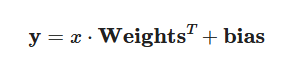

我们模型的这种原始输出，通常被称为 **logits**。
这就是模型接收输入数据（公式中的 x 或代码中的 X_test）后直接输出的内容——logits。
但这些数字很难直观解释，无法直接和标签对比。

我们需要把它们转换成和标签形式一致的数值。
要将模型的原始输出（logits）转换为可解释的形式，
可以使用 **sigmoid activation function（Sigmoid 激活函数）**。

In [77]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0', grad_fn=<SigmoidBackward0>)

好的，现在输出看起来具有一定的规律（尽管仍然是随机的）。
它们现在以**预测概率**的形式呈现（通常称为 y_pred_probs）。
换句话说，这些数值代表了模型认为当前数据点属于某一类别的置信程度。

在我们的二分类任务中，理想的输出是 0 或 1。
因此这些概率值可以看作一个**决策边界**。
数值越接近 0，模型越确信样本属于 0 类；
数值越接近 1，模型越确信样本属于 1 类。

具体规则如下：
如果 y_pred_probs >= 0.5，则预测为 y=1（1 类）
如果 y_pred_probs < 0.5，则预测为 y=0（0 类）

为了将预测概率转换为最终的预测标签，
我们可以对 Sigmoid 激活函数的输出进行四舍五入/取整。

In [78]:
# 求出预测标签（对预测概率进行四舍五入）
y_preds = torch.round(y_pred_probs)

# 完整写法（一步到位）
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# 检查两种写法结果是否一致
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# 去掉多余的维度
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

太棒了！现在我们模型的预测结果，看起来和真实标签（y_test）的格式完全一致了。

In [79]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

这意味着我们将能够将我们的模型预测与测试标签进行比较，以了解它的进展情况。

回顾一下，我们使用 sigmoid 激活函数将模型的原始输出（logits）转换为预测概率。

然后通过四舍五入将预测概率转换为预测标签。

>注意： sigmoid 激活函数的使用通常只用于二分类 logits。 对于多类分类，我们将研究使用 softmax 激活函数（稍后会出现）。

> 并且在将模型的原始输出传递给 nn.BCEWithLogitsLoss 时不需要使用 sigmoid 激活函数（logits 损失中的“logits”是因为它适用于模型的原始 logits 输出），这是因为它具有 内置的 sigmoid 函数。

#### 3.2 创建训练和测试循环

In [80]:
# 固定随机种子，让结果可复现（每次运行结果一样）
torch.manual_seed(42)

# 设置训练总轮数：模型把全部数据看 100 遍
epochs = 100

# 把训练/测试数据都搬到指定设备（CPU 或 GPU）
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# =====================
# 训练 + 测试 循环（核心 loop）
# =====================
for epoch in range(epochs):  # 循环 100 次
    ### 1. 训练模式
    model_0.train()

    # 前向传播：模型输出原始值 logits
    y_logits = model_0(X_train).squeeze()  # 去掉多余维度

    # logits → 概率 → 预测标签（0 或 1）
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 计算损失和准确率
    # 重点：用 BCEWithLogitsLoss 直接喂 logits，不用手动 sigmoid！
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 梯度清零（非常重要，避免累积）
    optimizer.zero_grad()

    # 反向传播：计算梯度
    loss.backward()

    # 优化器更新模型参数
    optimizer.step()

    ### 2. 测试模式（不更新梯度，只评估）
    model_0.eval()
    with torch.inference_mode():  # 关闭梯度计算，加速+省内存
        # 测试集前向传播
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 测试集损失与准确率
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # 每 10 轮打印一次结果
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69440, Test acc: 58.00%
Epoch: 10 | Loss: 0.69590, Accuracy: 51.25% | Test loss: 0.69305, Test acc: 53.00%
Epoch: 20 | Loss: 0.69490, Accuracy: 51.62% | Test loss: 0.69254, Test acc: 49.50%
Epoch: 30 | Loss: 0.69435, Accuracy: 51.12% | Test loss: 0.69236, Test acc: 49.50%
Epoch: 40 | Loss: 0.69401, Accuracy: 50.88% | Test loss: 0.69232, Test acc: 51.00%
Epoch: 50 | Loss: 0.69378, Accuracy: 50.25% | Test loss: 0.69234, Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Accuracy: 50.00% | Test loss: 0.69239, Test acc: 51.50%
Epoch: 70 | Loss: 0.69351, Accuracy: 50.25% | Test loss: 0.69246, Test acc: 51.00%
Epoch: 80 | Loss: 0.69342, Accuracy: 49.88% | Test loss: 0.69254, Test acc: 50.00%
Epoch: 90 | Loss: 0.69336, Accuracy: 49.88% | Test loss: 0.69262, Test acc: 53.00%


模型现象分析：准确率始终 50%

1. 现象
   - 模型训练了很多轮（epochs）
   - 训练/测试准确率**一直停留在 50%**
   - 损失几乎不下降
   - 预测结果**完全没有进步**
2. 这意味着什么？
   在**平衡二分类问题**中：
   - 数据里 0 和 1 各占一半（各 500 个）
   - 模型**永远只猜其中一类**（比如永远猜 1）
   - 正确率 = 50%
结论：
✅ **模型 = 随机猜测**
❌ **模型 = 没有学到任何东西**
3. 为什么会这样？（最常见 4 个原因）
   1. 模型太简单（最常见！）
      - 只有一层线性层，无法拟合非线性数据
      - 相当于用直线去分弯曲的数据 → 分不动

   2. 没有使用非线性激活函数
      - 缺少 ReLU / sigmoid 等
      - 多层神经网络变成了“单层线性模型”，等于白搭

   3. 学习率不适合
      - 学习率太大 → 不收敛
      - 学习率太小 → 几乎不更新

   4. 数据问题
      - 数据无法区分（特征和标签无关）
      - 标准化/归一化没做
      - 数据没放到正确设备（GPU/CPU 不匹配）

## 4. 预测和评估模型

1. 模型准确率 50% = 瞎猜
2. 看数字没用 → 必须画图看
3. 决策边界（decision boundary） = 模型用来区分 “0 还是 1” 的那条线
4. plot_decision_boundary() = 自动画出模型在哪分 0、哪分 1
5. 一画图，你立刻就能看到模型为什么学不会！

In [81]:
# 下载辅助函数文件（不用自己写画图代码）
import requests
from pathlib import Path

# 检查文件是否已经存在
if Path("../../utils/helper_functions.py").is_file():
  # 如果已经下载过，就跳过
  print("helper_functions.py 已存在，跳过下载")
else:
  # 如果不存在，从 GitHub 下载文件
  print("正在下载 helper_functions.py...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")

  # 把下载的内容保存成 .py 文件
  with open("../../utils/helper_functions.py", "wb") as f:
    f.write(request.content)

# 从辅助文件中导入两个超级有用的画图函数
from utils.helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py 已存在，跳过下载


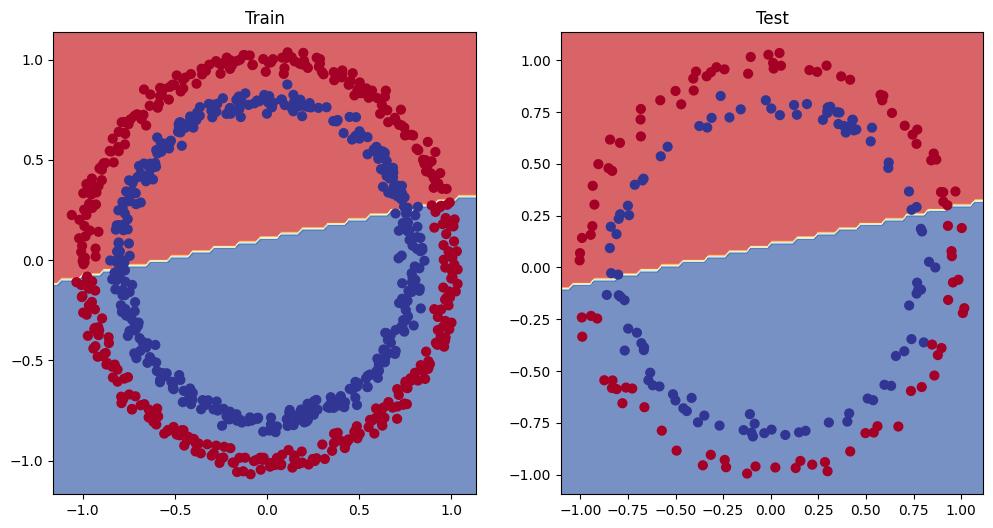

In [82]:
# 绘制 训练集 & 测试集 的决策边界图
plt.figure(figsize=(12, 6))  # 设置整张图的大小

# 左边子图：训练集决策边界
plt.subplot(1, 2, 1)       # 1行2列，第1个图
plt.title("Train")         # 标题：训练集
plot_decision_boundary(model_0, X_train, y_train)  # 画模型分界线

# 右边子图：测试集决策边界
plt.subplot(1, 2, 2)       # 1行2列，第2个图
plt.title("Test")          # 标题：测试集
plot_decision_boundary(model_0, X_test, y_test)    # 画模型分界线

看来我们找到了模型性能问题的原因。

它目前正在尝试使用直线分割红点和蓝点......

这就解释了 50% 的准确率。 由于我们的数据是圆形的，所以画一条直线最多只能从中间切开。

在机器学习方面，我们的模型是underfitting欠拟合，这意味着它没有从数据中学习预测模式。

我们该如何改进呢？

## 5. 改进模型

| Model improvement technique* | What does it do? |
| ----------------------------- | ---------------- |
| Add more layers | 每一层潜在地增加模型的学习能力，每一层都能够学习数据中的某种新模式，更多的层通常被称为使你的神经网络更深。 |
| Add more hidden units | 与上述类似，每层更多的隐藏单元意味着模型学习能力的潜在增加，更多的隐藏单元通常被称为使您的神经网络更宽。 |
| 训练更久 (more epochs) | 如果您的模型有更多机会查看数据，它可能会学到更多。 |
| Changing the activation functions | 有些数据不能只用直线拟合（就像我们看到的那样），使用非线性激活函数可以帮助解决这个问题（提示，提示）。 |
| Change the learning rate | 不太具体的模型，但仍然相关，优化器的学习率决定了模型每一步应该改变多少参数，太多，模型过度校正，太少，它学习不够。 |
| Change the loss function | 同样，模型特定性较低但仍然很重要，不同的问题需要不同的损失函数。 例如，二元交叉熵损失函数不适用于多类分类问题。 |
| Use transfer learning | 从与您的问题域相似的问题域中获取预训练模型，并将其调整为您自己的问题。 我们涵盖了迁移学习在 notebook 06. |

超参数说明
>注意：*这些可以手动修改调整的参数，统称为 **超参数（hyperparameters）**。

这是机器学习**一半是艺术、一半是科学**的地方。
没有绝对正确的方法能直接知道项目的最佳超参数组合。
最好的方式是遵循数据科学家的座右铭：
**"实验、实验、实验！"**

如果我们在模型中添加一个额外的层会发生什么，以适应更长的时间（epochs=1000 而不是 epochs=100）并将隐藏单元的数量从 5 增加到 10。

我们将遵循与上面相同的步骤，但更改了一些超参数。

In [83]:
# 改进版圆形分类模型 V1
# 增加了层数 + 隐藏单元，尝试拟合非线性数据
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 第一层：输入2个特征 → 10个隐藏单元
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        # 第二层：10 → 10（新增的层！让模型更深）
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        # 第三层：10 → 1（输出1个值，二分类）
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # 前向传播：数据一层一层传递
        return self.layer_3(self.layer_2(self.layer_1(x)))

# 创建模型并搬到设备（CPU/GPU）
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

现在我们已经有了模型，接下来将重新创建损失函数和优化器实例，并使用和之前相同的设置。

In [84]:
# 损失函数与优化器定义

# 二选一，不要同时用：
# loss_fn = nn.BCELoss()          # 需要手动对输入做 sigmoid
loss_fn = nn.BCEWithLogitsLoss()   # 自带 sigmoid，无需手动添加

# 优化器：SGD，学习率 lr=0.1
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

模型、优化器和损失函数都已准备就绪，我们来构建训练循环吧。
这一次我们将延长训练时间（训练轮数从 100 轮改为 1000 轮），看看能否提升模型效果。

In [85]:
# 设置随机种子，保证结果可复现
torch.manual_seed(42)

# 训练总轮数：延长训练至1000轮
epochs = 1000

# 将所有数据移动到指定设备（CPU/GPU）
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# 开始训练与测试循环
for epoch in range(epochs):
    ### 训练阶段
    # 1. 前向传播
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))  # 原始输出 -> 概率 -> 预测标签

    # 2. 计算损失与准确率
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. 优化器梯度清零
    optimizer.zero_grad()

    # 4. 反向传播（计算梯度）
    loss.backward()

    # 5. 优化器更新模型参数
    optimizer.step()

    ### 测试阶段
    model_1.eval()
    with torch.inference_mode():
        # 1. 前向传播
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. 计算测试损失与准确率
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # 每100轮打印一次结果
    if epoch % 100 == 0:
        print(f"轮数: {epoch} | 损失: {loss:.5f}, 准确率: {acc:.2f}% | 测试损失: {test_loss:.5f}, 测试准确率: {test_acc:.2f}%")

轮数: 0 | 损失: 0.69396, 准确率: 50.88% | 测试损失: 0.69261, 测试准确率: 51.00%
轮数: 100 | 损失: 0.69305, 准确率: 50.38% | 测试损失: 0.69379, 测试准确率: 48.00%
轮数: 200 | 损失: 0.69299, 准确率: 51.12% | 测试损失: 0.69437, 测试准确率: 46.00%
轮数: 300 | 损失: 0.69298, 准确率: 51.62% | 测试损失: 0.69458, 测试准确率: 45.00%
轮数: 400 | 损失: 0.69298, 准确率: 51.12% | 测试损失: 0.69465, 测试准确率: 46.00%
轮数: 500 | 损失: 0.69298, 准确率: 51.00% | 测试损失: 0.69467, 测试准确率: 46.00%
轮数: 600 | 损失: 0.69298, 准确率: 51.00% | 测试损失: 0.69468, 测试准确率: 46.00%
轮数: 700 | 损失: 0.69298, 准确率: 51.00% | 测试损失: 0.69468, 测试准确率: 46.00%
轮数: 800 | 损失: 0.69298, 准确率: 51.00% | 测试损失: 0.69468, 测试准确率: 46.00%
轮数: 900 | 损失: 0.69298, 准确率: 51.00% | 测试损失: 0.69468, 测试准确率: 46.00%


 我们的模型训练了更长的时间并增加了一层，但看起来它仍然没有比随机猜测更好地学习任何模式。

让我们可视化。

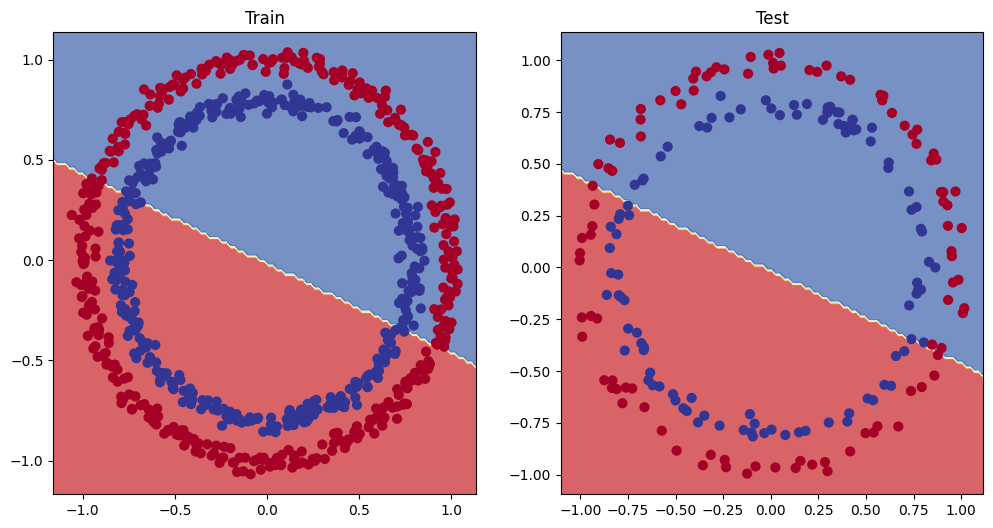

In [86]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

我们的模型仍在红点和蓝点之间画一条直线。 如果我们的模型正在绘制一条直线，它可以对线性数据进行建模吗？ 就像我们在 notebook 01

### 5.1 准备数据，看看我们的模型能否拟合一条直线

我们来创建一些线性数据，看看模型能否对其进行拟合，以此确认我们用的不是一个什么都学不会的模型。

In [87]:
# 创建数据（与第01节笔记相同）
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# 构造数据
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias  # 线性回归公式

# 查看数据
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

接下来分数据和测试集合

In [88]:
# 划分训练集和测试集
train_split = int(0.8 * len(X_regression)) # 80% 的数据用于训练集
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# 查看每一部分数据的长度
print(len(X_train_regression),
    len(y_train_regression),
    len(X_test_regression),
    len(y_test_regression))

80 80 20 20


让我们看看数据的样子。
为此，我们将使用在笔记 01 中创建的 plot_predictions() 函数。
它包含在我们上面下载的、Learn PyTorch for Deep Learning 仓库中的 helper_functions.py 脚本里。

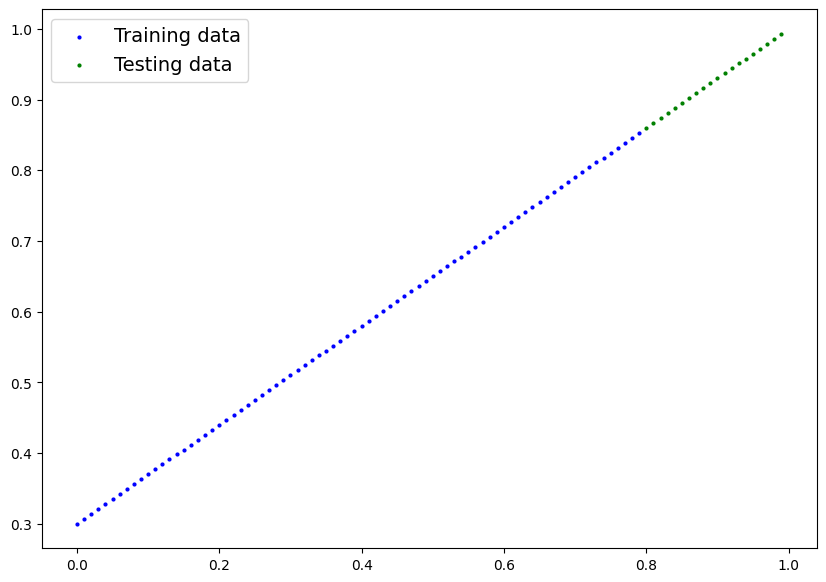

In [89]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

### 5.2 调整 model_1 以拟合一条直线

现在我们有了数据，让我们重新构建 model_1，并使用适合回归任务的损失函数。

In [90]:
# 与 model_1 结构相同（但使用 nn.Sequential 简化构建）
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

我们将损失函数设置为 nn.L1Loss()（等同于平均绝对误差），优化器设置为 torch.optim.SGD()。

In [91]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

现在让我们使用常规的训练循环步骤训练模型，总共训练 1000 个 epoch（和 model_1 一样）。
>注意：我们一直在反复编写相似的训练循环代码。不过我是故意这样设计的，目的是让你不断练习。但是，你有没有想过我们如何把这段代码函数化？这样未来可以节省大量的编码工作。我们或许可以写一个训练函数和一个测试函数。

In [92]:
# 训练模型
torch.manual_seed(42)

# 设置训练轮数
epochs = 1000

# 将数据移动到目标设备
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### 训练
    # 1. 前向传播
    y_pred = model_2(X_train_regression)

    # 2. 计算损失（回归问题无需计算准确率）
    loss = loss_fn(y_pred, y_train_regression)

    # 3. 优化器梯度清零
    optimizer.zero_grad()

    # 4. 反向传播
    loss.backward()

    # 5. 优化器更新参数
    optimizer.step()

    ### 测试
    model_2.eval()
    with torch.inference_mode():
      # 1. 前向传播
      test_pred = model_2(X_test_regression)
      # 2. 计算损失
      test_loss = loss_fn(test_pred, y_test_regression)

    # 每100轮打印结果
    if epoch % 100 == 0:
        print(f"轮数: {epoch} | 训练损失: {loss:.5f}, 测试损失: {test_loss:.5f}")

轮数: 0 | 训练损失: 0.75986, 测试损失: 0.54143
轮数: 100 | 训练损失: 0.09309, 测试损失: 0.02901
轮数: 200 | 训练损失: 0.07376, 测试损失: 0.02850
轮数: 300 | 训练损失: 0.06745, 测试损失: 0.00615
轮数: 400 | 训练损失: 0.06107, 测试损失: 0.02004
轮数: 500 | 训练损失: 0.05698, 测试损失: 0.01061
轮数: 600 | 训练损失: 0.04857, 测试损失: 0.01326
轮数: 700 | 训练损失: 0.06109, 测试损失: 0.02127
轮数: 800 | 训练损失: 0.05599, 测试损失: 0.01426
轮数: 900 | 训练损失: 0.05571, 测试损失: 0.00603


与在分类数据上的 model_1 不同，看起来 model_2的损失值确实在下降。
让我们绘制它的预测结果来确认这一点。
请记住，由于我们的模型和数据都在目标设备（可能是 GPU）上运行，而绘图函数使用的是 matplotlib，它无法直接处理 GPU 上的数据。
为了解决这个问题，我们在将数据传入 plot_predictions() 函数时，会使用 .cpu() 把所有数据送回 CPU。

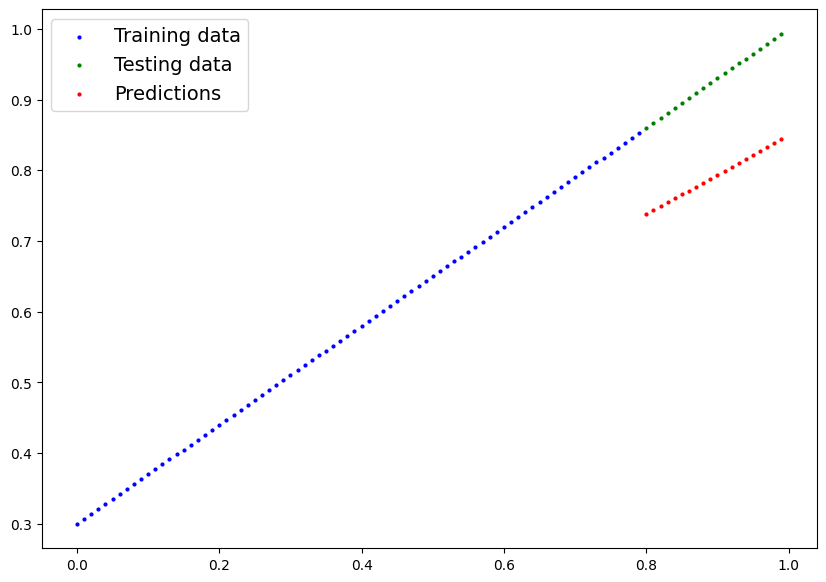

In [93]:
# 开启评估模式
model_2.eval()

# 模型预测（推理）
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# 绘图：数据必须先转到CPU（matplotlib无法处理GPU数据）
# （试着去掉其中一个 .cpu() 看看会发生什么）
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

好吧，看起来我们的模型比直线上的随机猜测要好得多。

这是一件好事。

这意味着我们的模型至少有一些的学习能力。

>注意： 在构建深度学习模型时，一个有用的故障排除步骤是从尽可能小的开始，以查看模型在放大之前是否有效。

>这可能意味着从一个简单的神经网络（层数不多，隐藏神经元数不多）和一个小数据集（就像我们制作的那个）开始，然后在其上进行过度拟合（使模型表现得太好） 在增加数据量或模型大小/设计以减少过度拟合之前的小例子。

那会是什么？

让我们来了解一下。

## 6. 缺失的部分：非线性

我们已经看到我们的模型可以绘制直线（线性），这要归功于它的线性层。

但是我们赋予它绘制非直线（非线性）线的能力怎么样？

### 6.1 重建非线性数据（红色和蓝色圆点）

首先，让我们重新创建数据，从头开始。我们会使用和之前相同的设置。

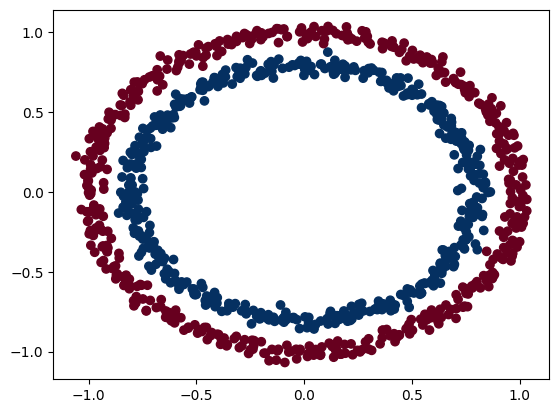

In [94]:
# 生成并绘制数据
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# 样本数量
n_samples = 1000

# 生成环形数据（非线性数据）
X, y = make_circles(n_samples=1000,
    noise=0.03,       # 噪声
    random_state=42,  # 随机种子，保证结果可复现
)

# 绘制散点图，红色与蓝色圆点
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

现在我们将数据划分为训练集和测试集，用 80% 的数据训练，20% 的数据测试。

In [95]:
# 转换为张量并划分训练集和测试集
import torch
from sklearn.model_selection import train_test_split

# 将数据转换为张量（浮点数类型）
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# 划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,   # 20% 用作测试
                                                    random_state=42  # 固定随机种子
)

# 查看前5个样本
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2用非线性构建模型

仅使用线性层的神经网络，本质上只能拟合线性规律，如同只用直线绘图，无法刻画曲线、圆形等复杂非线性数据模式。而引入 ReLU 等非线性激活函数后，模型能够打破线性限制，在隐藏层之间引入非线性变换，让神经网络具备拟合任意复杂函数与非线性分布数据的能力，从 “只能画直线” 升级为可学习复杂规律的通用模型，是深度网络解决实际非线性问题（如圆形分类、图像识别）的核心关键。

In [96]:
# 构建带非线性激活函数的模型
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # 3个线性层（负责学习特征）
        self.layer_1 = nn.Linear(in_features=2, out_features=10)  # 输入2个特征 → 10个神经元
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # 10 → 10
        self.layer_3 = nn.Linear(in_features=10, out_features=1) # 10 → 输出1个（二分类）

        # 非线性激活函数（核心！让模型能画曲线、拟合圆形）
        self.relu = nn.ReLU()

    def forward(self, x):
        # 前向传播：线性层 → ReLU → 线性层 → ReLU → 输出层
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)
        return x

# 创建模型并搬到设备（CPU/GPU）
model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


可以在 TensorFlow Playground网站上自己动手搭建一个。

在构建神经网络时，非线性激活函数应该放在哪里？
经验法则
一般把它们放在隐藏层之间、紧接在输出层之前，不过并没有一成不变的固定规则。随着你对神经网络和深度学习的学习加深，会发现各种各样的网络搭建方式。在此期间，最好的方法就是不断尝试、尝试、再尝试。

现在我们的模型已经准备就绪，接下来我们来定义一个二分类损失函数，同时选择一个优化器。

In [97]:
# 设置损失函数与优化器
# 二分类专用损失函数（自带Sigmoid）
loss_fn = nn.BCEWithLogitsLoss()
# 随机梯度下降优化器（更新模型参数，学习率0.1）
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

### 6.3 使用非线性（ReLU）训练模型

你已经熟悉这套流程了：模型、损失函数、优化器都已准备就绪，现在我们来创建训练循环与测试循环。

In [98]:
# 训练模型
torch.manual_seed(42)  # 设置随机种子，保证结果可复现
epochs = 1000          # 设定总训练轮数为1000轮

# 将所有数据移动到指定设备（CPU/GPU）
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# 开始循环训练
for epoch in range(epochs):
    # 1. 前向传播
    y_logits = model_3(X_train).squeeze()  # 模型输出原始预测值（logits）
    y_pred = torch.round(torch.sigmoid(y_logits))  # logits → 概率 → 最终分类标签

    # 2. 计算损失值和准确率
    loss = loss_fn(y_logits, y_train)  # BCEWithLogitsLoss 直接使用 logits 计算损失
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)   # 计算训练集准确率

    # 3. 优化器梯度清零（避免梯度累积）
    optimizer.zero_grad()

    # 4. 反向传播（计算参数梯度）
    loss.backward()

    # 5. 优化器更新参数（学习改错）
    optimizer.step()

    # ———————————— 测试阶段 ————————————
    model_3.eval()          # 切换模型为评估模式
    with torch.inference_mode():  # 关闭梯度计算，提升速度、节省内存
      # 1. 测试集前向传播
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))

      # 2. 计算测试集损失和准确率
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # 每100轮打印一次训练信息
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, 准确率: {acc:.2f}% | 测试损失: {test_loss:.5f}, 测试准确率: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, 准确率: 50.00% | 测试损失: 0.69319, 测试准确率: 50.00%
Epoch: 100 | Loss: 0.69115, 准确率: 52.88% | 测试损失: 0.69102, 测试准确率: 52.50%
Epoch: 200 | Loss: 0.68977, 准确率: 53.37% | 测试损失: 0.68940, 测试准确率: 55.00%
Epoch: 300 | Loss: 0.68795, 准确率: 53.00% | 测试损失: 0.68723, 测试准确率: 56.00%
Epoch: 400 | Loss: 0.68517, 准确率: 52.75% | 测试损失: 0.68411, 测试准确率: 56.50%
Epoch: 500 | Loss: 0.68102, 准确率: 52.75% | 测试损失: 0.67941, 测试准确率: 56.50%
Epoch: 600 | Loss: 0.67515, 准确率: 54.50% | 测试损失: 0.67285, 测试准确率: 56.00%
Epoch: 700 | Loss: 0.66659, 准确率: 58.38% | 测试损失: 0.66322, 测试准确率: 59.00%
Epoch: 800 | Loss: 0.65160, 准确率: 64.00% | 测试损失: 0.64757, 测试准确率: 67.50%
Epoch: 900 | Loss: 0.62362, 准确率: 74.00% | 测试损失: 0.62145, 测试准确率: 79.00%


### 6.4 评估使用非线性激活函数训练的模型
还记得我们的圆形数据是非线性的吗？现在模型已经用非线性激活函数训练完成，我们来看看它的预测效果如何。

In [99]:
# 模型预测
model_3.eval()               # 切换模型为评估模式
with torch.inference_mode(): # 关闭梯度计算（加速、省内存）
    # 1. 输入测试集 → 得到logits → 经过sigmoid转为概率 → 四舍五入为0/1标签
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

# 查看前10个预测结果 和 前10个真实标签
# 目的：让预测值格式与真实标签保持一致
y_preds[:10], y[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

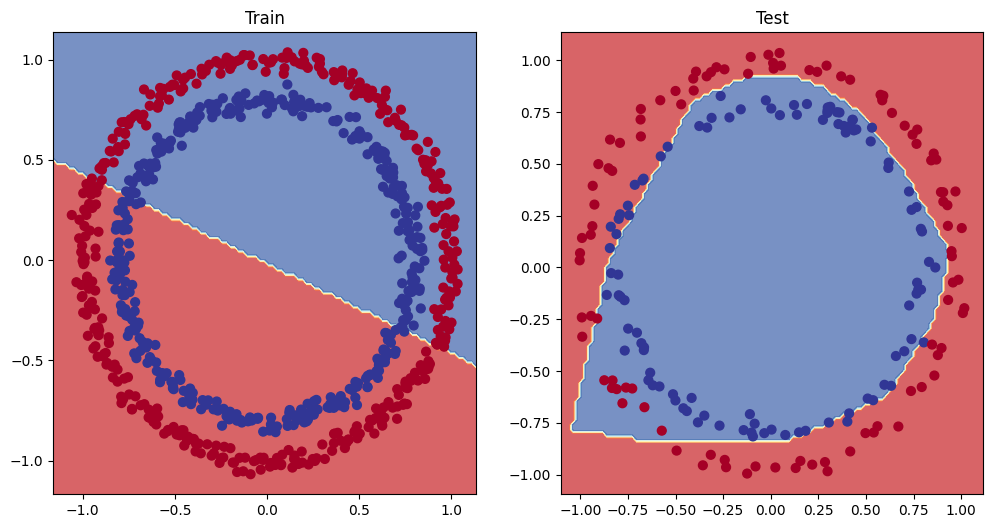

In [100]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

可以尝试一些技巧来提高模型的测试准确率（提示：回到第 5 节查看提升模型性能的技巧）

## 7. 实现非线性激活函数

我们之前已经看到，向模型中加入非线性激活函数，能够帮助模型对非线性数据进行建模。
>重点：你在现实世界中遇到的绝大多数数据都是非线性的（或是线性与非线性的混合）。

到目前为止，我们一直在使用二维平面上的点来做实验。但想象一下：如果你要对植物图片做分类，会遇到各种各样的植物形状；或者你要对维基百科文本做摘要，单词的组合方式千变万化（包含大量线性与非线性模式）。

但非线性激活函数到底长什么样？我们要怎样手动模拟它，并理解它的作用？
让我们先创建一小批数据，从这里开始讲起。

In [101]:
# 创建一个简单张量（类似于输入到模型中的数据）
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

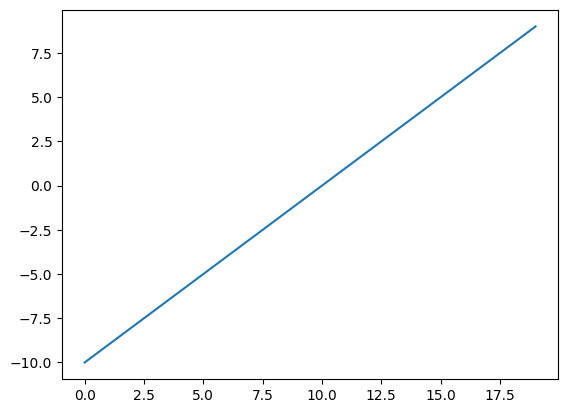

In [102]:
# Visualize the toy tensor
plt.plot(A);

现在让我们看看 ReLU 激活函数是如何影响它的。

我们将自己重新创建它，而不是使用 PyTorch 的 ReLU (torch.nn.ReLU)。

ReLU 函数将所有负数变为 0，并将正值保持原样。

In [103]:
# 导入PyTorch库
import torch

# 手动实现ReLU激活函数
def relu(x):
    """
    ReLU激活函数：f(x) = max(0, x)
    输入x必须是PyTorch张量
    """
    return torch.maximum(torch.tensor(0.0), x)  # 用0.0保证浮点型匹配，更稳定

# 1. 创建测试张量A
A = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0, 3.5])
print("原始张量 A：", A)

# 2. 将张量传入ReLU函数
output = relu(A)
print("ReLU处理后的结果：", output)

原始张量 A： tensor([-2.0000, -1.0000,  0.0000,  1.0000,  2.0000,  3.5000])
ReLU处理后的结果： tensor([0.0000, 0.0000, 0.0000, 1.0000, 2.0000, 3.5000])


看起来我们的 ReLU 函数起作用了，所有的负值都是零。

让我们绘制它们。

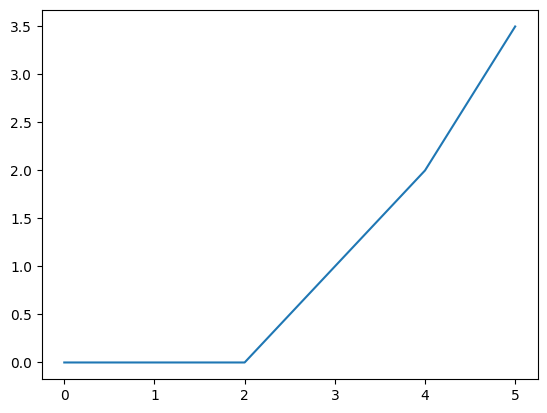

In [104]:
# Plot ReLU activated toy tensor
plt.plot(relu(A));

这看起来和维基百科上 ReLU 词条里的函数图像一模一样。
那我们来试试之前一直在用的Sigmoid（S 型）函数怎么样？
Sigmoid 函数的公式是这样的：

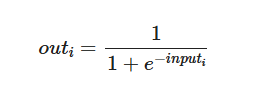

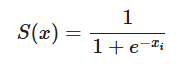

其中 S 代表 Sigmoid 函数，e 代表指数运算（对应 PyTorch 中的 torch.exp()），x 代表张量中的某个元素。
让我们用 PyTorch 编写一个函数来实现 Sigmoid 函数。

In [105]:
# 创建自定义的sigmoid函数
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# 使用测试张量测试自定义sigmoid函数
sigmoid(A)

tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808, 0.9707])

这些数值看起来和我们之前见过的预测概率非常像，我们来可视化看看它们长什么样

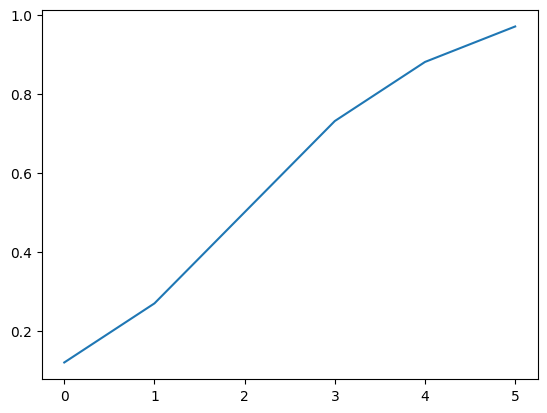

In [106]:
# Plot sigmoid activated toy tensor
plt.plot(sigmoid(A));

看起来很不错！我们已经从直线过渡到了曲线。非线性激活函数的种类有很多，但ReLU 和 Sigmoid 是其中最常用的两个。

这里有一个核心问题：如果可以使用无数条线性（直线）与非线性（曲线）函数，能画出什么样的图案？
答案是：几乎任何图案都可以。

而这正是神经网络模型在做的事情 ——组合线性与非线性函数。我们不需要手动告诉模型具体该如何拟合，而是为它提供基础工具，让模型自己去学习、发现数据中潜藏的规律与模式。

这些核心工具，就是线性变换和非线性激活函数。

## 8.组合起来，实现一个多分类模型

回想一下 二元分类 问题处理将某物分类为两个选项之一（例如，一张照片作为猫照片或狗照片），而 多类分类 问题处理从列表中对某物进行分类 超过两个选项（例如，将照片分类为猫、狗或鸡）。

### 8.1 创建多类别数据

要开始解决多分类问题，我们首先需要创建一些多分类数据。实现这一点可以借助 Scikit-Learn 库中的 make_blobs() 方法。该方法能够根据我们的需求，创建指定数量的类别（通过 centers 参数控制）。

具体操作步骤如下：
1. 使用 make_blobs() 创建多分类数据集；
2. 将数据转换为张量格式（make_blobs() 默认生成 NumPy 数组）；
3. 利用 train_test_split() 将数据集划分为训练集和测试集；
4. 对数据进行可视化展示。

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


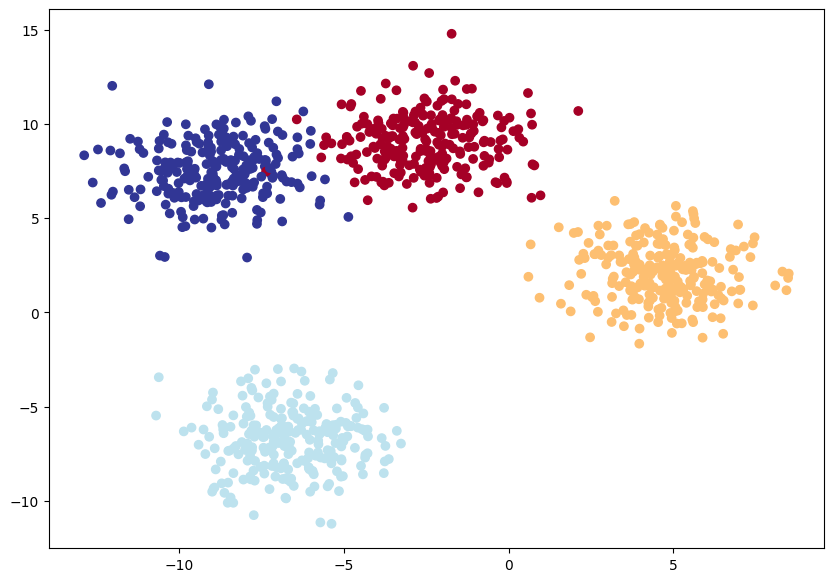

In [107]:
# 导入依赖库
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# 数据创建相关超参数设置
NUM_CLASSES = 4    # 类别数量
NUM_FEATURES = 2   # 特征数量（2维方便画图）
RANDOM_SEED = 42   # 随机种子，保证结果可复现

# 1. 创建多分类数据集
X_blob, y_blob = make_blobs(n_samples=1000,       # 总样本数
                            n_features=NUM_FEATURES,  # 特征数
                            centers=NUM_CLASSES,      # 类别中心数（决定分类数）
                            cluster_std=1.5,          # 簇的标准差（数值越大簇越分散）
                            random_state=RANDOM_SEED)

# 2. 数据类型转换：numpy array → pytorch 张量
# 特征用 float32 类型
X_blob = torch.from_numpy(X_blob).type(torch.float)
# 标签用长整型（多分类任务 CrossEntropy 要求）
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 查看前5个样本
print(X_blob[:5], y_blob[:5])

# 3. 划分训练集与测试集（80%训练，20%测试）
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob,
    test_size=0.2,        # 测试集占比20%
    random_state=RANDOM_SEED
)

# 4. 数据可视化
plt.figure(figsize=(10, 7))
# 散点图，颜色按标签区分
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.show()

太棒了！看起来我们的多分类数据已经准备就绪。
接下来我们搭建一个模型，把这些不同颜色的簇分开。
问题：这个数据集需要非线性激活函数吗？还是说，只用一系列直线就能把它们分开？

### 8.2 在 PyTorch 中搭建多分类模型

到目前为止，我们已经在 PyTorch 中搭建了好几个模型。你可能也开始逐渐体会到神经网络极高的灵活性了。接下来，我们搭建一个与 `model_3` 结构相似、但能处理多分类任务的模型。

具体实现方式：创建一个继承自 `nn.Module` 的子类，它接收三个超参数：
- `input_features`：输入模型的特征数量（X 的维度）
- `output_features`：期望的输出特征数量（等于类别数 NUM_CLASSES）
- `hidden_units`：每个隐藏层使用的隐藏神经元数量
同时，我们会编写设备无关代码（GPU/CPU 自动适配），这是工程中的标准写法（在同一个 notebook 里只需设置一次）。

最后，用上面的超参数定义完整的模型类。

In [108]:
# 创建设备无关代码：自动选择 GPU(如果可用)，否则用 CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# 打印当前使用的设备
print(f"使用的设备: {device}")

使用的设备: cuda


In [109]:
import torch
from torch import nn

# ====================== 设备无关代码 ======================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

# ====================== 超参数 ======================
NUM_FEATURES = 2    # 输入特征（比如二维坐标数据）
NUM_CLASSES = 4     # 分成 4 类
HIDDEN_UNITS = 8    # 隐藏层神经元

# ====================== 构建模型 ======================
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# ====================== 创建模型并放到设备上 ======================
model_4 = BlobModel(
    input_features=NUM_FEATURES,
    output_features=NUM_CLASSES,
    hidden_units=HIDDEN_UNITS
).to(device)

# 查看模型
model_4

使用设备: cuda


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 为 PyTorch 多分类模型创建损失函数与优化器

由于我们正在解决多分类任务，因此将使用 `nn.CrossEntropyLoss()` 方法作为我们的损失函数。

并且我们将继续使用学习率为 0.1 的随机梯度下降（SGD）优化器，来优化 model_4 的参数。

In [110]:
# 创建损失函数和优化器
loss_fn = nn.CrossEntropyLoss()  # 多分类交叉熵损失
optimizer = torch.optim.SGD(     # 随机梯度下降优化器
    model_4.parameters(),        # 要优化的模型参数
    lr=0.1                       # 学习率（尝试修改这个值，观察模型效果变化）
)

### 8.4 为 PyTorch 多分类模型获取预测概率

好了，我们已经准备好损失函数和优化器，也准备好训练模型了。但在正式训练之前，我们先让模型执行一次前向传播，测试模型是否能正常运行。

In [111]:
# 对数据执行一次前向传播（必须先将数据放到目标设备上，代码才能正常运行）
model_4(X_blob_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='cuda:0',
       grad_fn=<SliceBackward0>)

看起来我们每个样本的每个特征都有一个值。

让我们检查形状以确认。

In [112]:
# 单个预测样本中有多少个元素？
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

太棒了，我们的模型为我们拥有的每个类别预测一个值。

你还记得我们模型的原始输出叫什么吗？

提示：它与“frog splits”押韵（在这些材料的制作过程中没有伤害任何动物）。

如果您猜到了 `logits`，那么您是正确的。

所以现在我们的模型正在输出 logits，但是如果我们想确切地确定哪个标签给出了样本呢？

就像我们对二元分类问题所做的那样，我们如何从“`logits` -> 预测概率 -> 预测标签”开始？

这就是 `softmax` 激活函数 发挥作用的地方。

`softmax` 函数计算每个预测类别与所有其他可能类别相比成为实际预测类别的概率。

让我们看看代码。

In [113]:
# 使用模型进行预测，输出原始预测值（logits）
y_logits = model_4(X_blob_test.to(device))

# 在维度1上对 logits 执行 softmax 计算，得到预测概率
y_pred_probs = torch.softmax(y_logits, dim=1)
# 打印前5个原始输出 logits
print(y_logits[:5])
# 打印前5个预测概率
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0',
       grad_fn=<SliceBackward0>)


看起来 `softmax` 函数的输出仍然是混杂的数字（它们确实是，因为我们的模型还没有经过训练并且正在使用随机模式进行预测），但是每个样本都有一个非常具体的不同之处。

在通过 `softmax` 函数传递 `logits` 之后，每个单独的样本现在加到 1（或非常接近）。

让我们检查。

In [114]:
# 对 softmax 激活函数输出的第一个样本进行求和
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

这些预测概率本质上是说模型认为目标“X”样本（输入）映射到每个类的程度。

由于 y_pred_probs 中的每个类都有一个值，highest 值的索引是模型认为特定数据样本 most 所属的类。

我们可以使用`torch.argmax()`检查哪个索引具有最高值。

In [115]:
# 对于索引为 0 的样本，模型认为哪个类别最有可能？
print(y_pred_probs[0])  # 打印第 0 个样本的所有类别预测概率
print(torch.argmax(y_pred_probs[0]))  # 找出概率值最大的那个类别索引

tensor([0.1872, 0.2918, 0.1495, 0.3715], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='cuda:0')


您可以看到 torch.argmax() 的输出返回 3，因此对于索引 0 处样本的特征（X），模型预测最可能的类值（y）是 3。

当然，现在这只是随机猜测，所以它有 25% 的机会是正确的（因为有四个类）。 但是我们可以通过训练模型来提高这些机会。

>注意： 综上所述，模型的原始输出称为 logits。

> 对于多类分类问题，要将 logits 转换为预测概率，请使用 softmax 激活函数 (torch.softmax)。

>具有最高预测概率的值的索引是模型认为在给定该样本的输入特征的情况下最可能可能的类别编号（虽然这是一个预测，但这并不意味着它是正确的 ）。

### 8.5 创建 PyTorch 多分类模型的训练与测试循环

好的，现在我们已经完成了所有准备步骤，让我们编写一个训练和测试循环来改进和评估我们的模型。

我们已经完成了其中的许多步骤，然后才将其中的大部分内容付诸实践。

唯一的区别是我们将调整步骤以将模型输出（logits）转换为预测概率（使用 softmax 激活函数），然后转换为预测标签（通过获取 softmax 激活函数输出的 argmax）。

让我们为 epochs=100 训练模型并每 10 个 epoch 评估一次。

In [116]:
# 训练模型（拟合数据）
torch.manual_seed(42)  # 固定随机种子，让结果可复现

# 设置训练轮数
epochs = 100

# 将所有数据移动到目标设备（GPU/CPU）
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# 开始循环训练
for epoch in range(epochs):
    # ==================== 训练阶段 ====================
    model_4.train()  # 开启模型训练模式

    # 1. 前向传播
    y_logits = model_4(X_blob_train)  # 模型输出原始 logits
    # logits → 概率 → 最终类别
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # 2. 计算损失值 和 准确率
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    # 3. 优化器梯度清零（非常重要！）
    optimizer.zero_grad()

    # 4. 反向传播（计算梯度）
    loss.backward()

    # 5. 优化器更新参数（让模型学得更好）
    optimizer.step()

    # ==================== 测试阶段 ====================
    model_4.eval()  # 开启评估/测试模式
    with torch.inference_mode():  # 关闭梯度计算，加速推理
        # 1. 前向传播
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

        # 2. 计算测试损失 和 测试准确率
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    # 每 10 轮打印一次训练信息
    if epoch % 10 == 0:
        print(f"轮数: {epoch} | 训练损失: {loss:.5f}, 训练准确率: {acc:.2f}% | 测试损失: {test_loss:.5f}, 测试准确率: {test_acc:.2f}%")

轮数: 0 | 训练损失: 1.04324, 训练准确率: 65.50% | 测试损失: 0.57861, 测试准确率: 95.50%
轮数: 10 | 训练损失: 0.14398, 训练准确率: 99.12% | 测试损失: 0.13037, 测试准确率: 99.00%
轮数: 20 | 训练损失: 0.08062, 训练准确率: 99.12% | 测试损失: 0.07216, 测试准确率: 99.50%
轮数: 30 | 训练损失: 0.05924, 训练准确率: 99.12% | 测试损失: 0.05133, 测试准确率: 99.50%
轮数: 40 | 训练损失: 0.04892, 训练准确率: 99.00% | 测试损失: 0.04098, 测试准确率: 99.50%
轮数: 50 | 训练损失: 0.04295, 训练准确率: 99.00% | 测试损失: 0.03486, 测试准确率: 99.50%
轮数: 60 | 训练损失: 0.03910, 训练准确率: 99.00% | 测试损失: 0.03083, 测试准确率: 99.50%
轮数: 70 | 训练损失: 0.03643, 训练准确率: 99.00% | 测试损失: 0.02799, 测试准确率: 99.50%
轮数: 80 | 训练损失: 0.03448, 训练准确率: 99.00% | 测试损失: 0.02587, 测试准确率: 99.50%
轮数: 90 | 训练损失: 0.03300, 训练准确率: 99.12% | 测试损失: 0.02423, 测试准确率: 99.50%


### 8.6 使用 PyTorch 多分类模型进行预测与评估

看起来我们训练好的模型表现相当不错。

不过为了确认这一点，我们来做一些预测并将结果可视化。

In [117]:
# 进行预测
model_4.eval()               # 将模型设置为评估模式
with torch.inference_mode(): # 开启推理模式（关闭梯度计算，加速预测）
    y_logits = model_4(X_blob_test) # 对测试集数据进行前向传播，得到原始输出

# 查看前 10 个预测的原始输出
y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0726,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5309,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]], device='cuda:0')


好吧，看起来我们模型的预测仍然是 `logit` 形式。

虽然要评估它们，但它们必须与我们的标签 (`y_blob_test`) 采用相同的形式，它们是整数形式。

让我们将模型的预测 `logits` 转换为预测概率（使用 `torch.softmax()`），然后转换为预测标签（通过获取每个样本的 `argmax()`）。

>注意： 可以通过直接在 `logits` 上调用 `torch.argmax()` 来跳过 `torch.softmax()` 函数并直接从 `predicted logits` -> 预测标签`开始。

>例如，`y_preds`= torch.argmax(y_logits, dim=1)`，这节省了一个计算步骤（没有`torch.softmax()`），但导致没有可用的预测概率。

In [118]:
# 将模型输出的原始预测值（logits）转换为预测概率
y_pred_probs = torch.softmax(y_logits, dim=1)

# 将预测概率转换为最终的预测类别标签
y_preds = y_pred_probs.argmax(dim=1)

# 对比模型前10个预测结果 和 测试集真实标签
print(f"预测结果: {y_preds[:10]}\n真实标签: {y_blob_test[:10]}")
# 计算并打印测试集准确率
print(f"测试准确率: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

预测结果: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
真实标签: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
测试准确率: 99.5%


好的！ 我们的模型预测现在与我们的测试标签采用相同的形式。

让我们用 `plot_decision_boundary()` 将它们可视化，记住因为我们的数据在 GPU 上，我们必须将其移动到 CPU 以与 matplotlib 一起使用（`plot_decision_boundary()`会自动为我们执行此操作）。

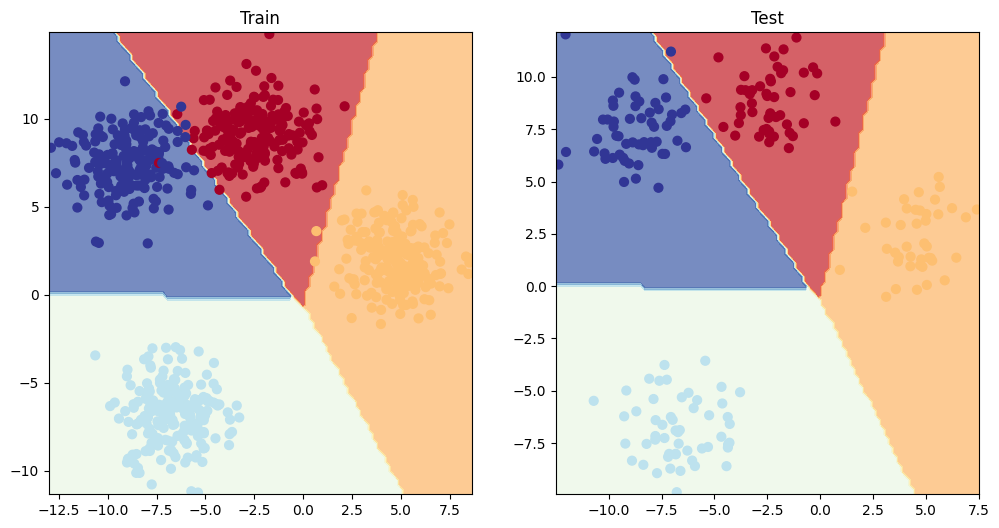

In [119]:
# 创建画布，设置大小为宽12、高6
plt.figure(figsize=(12, 6))

# 创建第一个子图（1行2列中的第1个位置）
plt.subplot(1, 2, 1)
# 设置标题：训练集
plt.title("Train")
# 绘制模型在训练集上的决策边界
plot_decision_boundary(model_4, X_blob_train, y_blob_train)

# 创建第二个子图（1行2列中的第2个位置）
plt.subplot(1, 2, 2)
# 设置标题：测试集
plt.title("Test")
# 绘制模型在测试集上的决策边界
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. 更多分类任务评估指标

到目前为止，我们只介绍了几种评估分类模型的方法（准确性、损失和可视化预测）。

这些是您会遇到的一些最常见的方法，并且是一个很好的起点。

但是，您可能希望使用更多指标来评估您的分类模型

| 指标名称/评估方法 | 定义                                                         | 代码 |
| :--- |:-----------------------------------------------------------| :--- |
| 准确率（Accuracy） | 在100次预测中，模型猜对了多少次？例如95%的准确率表示100次预测中猜对了95次。                | `torchmetrics.Accuracy(.)` 或 `sklearn.metrics.accuracy_score(.)` |
| 精确率（Precision） | 模型预测为某类的样本中，真正属于该类的比例。精确率越高，模型误判其他类别为该类的情况越少。              | `torchmetrics.Precision(.)` 或 `sklearn.metrics.precision_score(.)` |
| 召回率（Recall） | 实际属于某类的样本中，被模型正确预测为该类的比例。召回率越高，模型漏判该类样本的情况越少。              | `torchmetrics.Recall(.)` 或 `sklearn.metrics.recall_score(.)` |
| F1分数（F1-score） | 精确率和召回率的调和平均数，综合评估模型性能。1为最优，0为最差。                          | `torchmetrics.F1Score(.)` 或 `sklearn.metrics.f1_score(.)` |
| 混淆矩阵（Confusion matrix） | 以表格形式直观对比模型的预测类别与真实类别。若模型100%预测正确，矩阵中所有正确预测值会沿左上到右下的对角线分布。 | `torchmetrics.ConfusionMatrix` 或 `sklearn.metrics.plot_confusion_matrix(.)` |
| 分类报告（Classification report） | 汇总精确率、召回率、F1分数等核心分类指标的完整评估报告，支持多分类场景下按类别分别展示指标。            | `sklearn.metrics.classification_report(.)` |

Scikit-Learn（一个流行且世界级的机器学习库）已经实现了上述许多评估指标。如果你想要类似 PyTorch 风格的版本，可以查看 TorchMetrics，尤其是 TorchMetrics 的分类指标部分。

让我们来试用一下 `torchmetrics.Accuracy` 准确率指标。

In [120]:
# 静默安装 torchmetrics 库（用于计算深度学习评估指标）
!pip -q install torchmetrics --user

# 从 torchmetrics 库中导入 准确率 评估工具
from torchmetrics import Accuracy

# 初始化准确率指标，并确保它运行在目标设备（GPU/CPU）上
torchmetrics_accuracy = Accuracy().to(device)

# 计算模型预测的准确率（传入 预测值 和 真实标签）
torchmetrics_accuracy(y_preds, y_blob_test)

TypeError: Accuracy.__new__() missing 1 required positional argument: 'task'